# What Drives the Price of a Car?
## A CRISP-DM Analysis for Used Car Dealerships

**Author:** Avirup Dandapat 
**Date:** April 2026  

---

## Table of Contents
1. [Business Understanding](#1-business-understanding)
2. [Data Understanding](#2-data-understanding)
3. [Data Preparation](#3-data-preparation)
4. [Modeling](#4-modeling)
5. [Evaluation](#5-evaluation)
6. [Findings & Recommendations](#6-findings--recommendations)


---
## 1. Business Understanding

### Problem Statement

A used car dealership wants to understand **what features drive the price of used vehicles** so they can:
- Optimise their inventory by stocking vehicles consumers are willing to pay more for
- Price their inventory more accurately and competitively
- Identify high-value opportunities when purchasing vehicles at auction or from private sellers

### Goal

Build a predictive model for used car prices and identify which vehicle attributes are the **strongest predictors of price**. Translate those findings into clear, actionable recommendations for a non-technical audience.

### Success Criteria

- A regression model with good generalisation (measured by **R² and RMSE on log-price**)
- Clear interpretation of which features most influence price
- Actionable recommendations grounded in the data



## 2. Data Understanding


In [1]:
# ── Standard imports ─────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

# ── Plot defaults ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 100, 'figure.facecolor': 'white'})

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Load the dataset
df = pd.read_csv('../data/vehicles.csv')
print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset shape: 426,880 rows × 18 columns


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [4]:
# Summary statistics for numeric columns
df.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


### 2.1 Missing Value Analysis


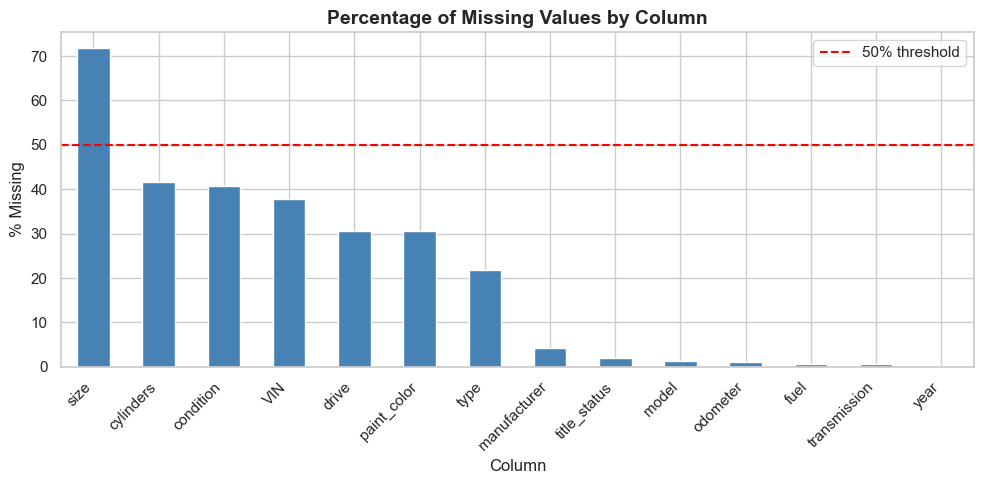

size            71.767476
cylinders       41.622470
condition       40.785232
VIN             37.725356
drive           30.586347
paint_color     30.501078
type            21.752717
manufacturer     4.133714
title_status     1.930753
model            1.236179
odometer         1.030735
fuel             0.705819
transmission     0.598763
year             0.282281


In [5]:
# Calculate and visualise percentage of missing values per column
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(10, 5))
missing.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Percentage of Missing Values by Column', fontsize=14, fontweight='bold')
ax.set_xlabel('Column')
ax.set_ylabel('% Missing')
ax.axhline(50, color='red', linestyle='--', label='50% threshold')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(missing.to_string())

**Observation:** `size` (~72% missing) and `VIN` (~38%) carry very limited information. `condition`, `cylinders`, `drive`, and `paint_color` are each missing in 30–40% of rows. These will require careful imputation or exclusion during preparation.


### 2.2 Target Variable — Price


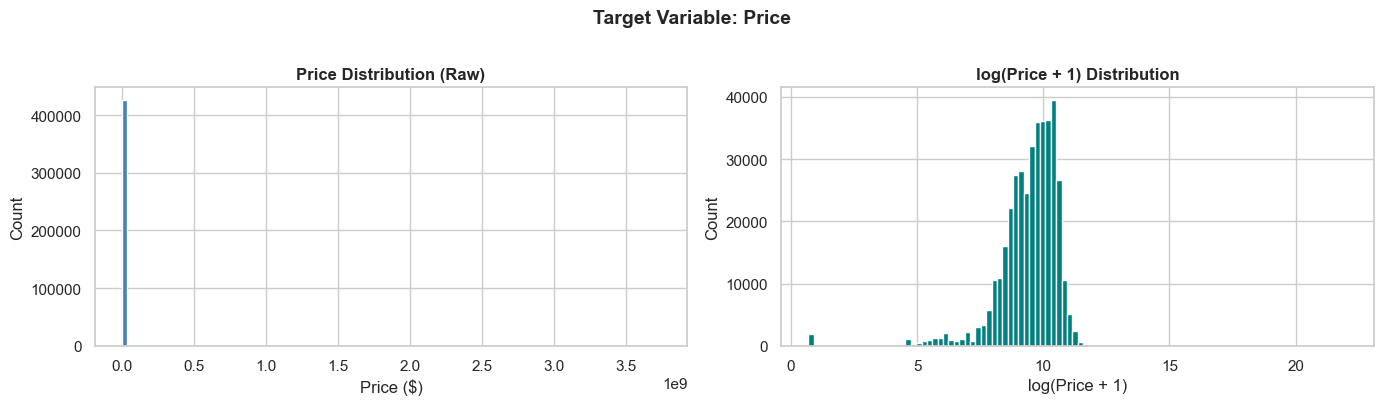

Price range: $0 — $3,736,928,711
Prices == 0: 32,895
Prices > $100,000: 655


In [6]:
# Distribution of raw prices — highly skewed with extreme outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['price'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (Raw)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')

# Log-transformed for better visibility
log_price = np.log1p(df.loc[df['price'] > 0, 'price'])
axes[1].hist(log_price, bins=100, color='teal', edgecolor='white')
axes[1].set_title('log(Price + 1) Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Count')

plt.suptitle('Target Variable: Price', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Price range: ${df['price'].min():,.0f} — ${df['price'].max():,.0f}")
print(f"Prices == 0: {(df['price'] == 0).sum():,}")
print(f"Prices > $100,000: {(df['price'] > 100_000).sum():,}")

### 2.3 Key Feature Distributions


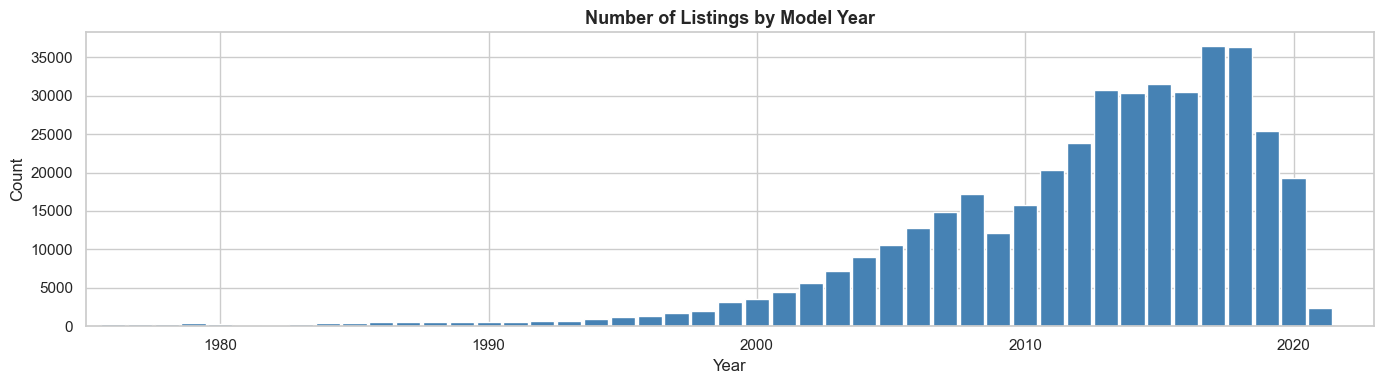

In [7]:
# Year distribution
year_counts = df['year'].dropna().astype(int).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(year_counts.index, year_counts.values, color='steelblue', edgecolor='white', width=0.9)
ax.set_title('Number of Listings by Model Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.set_xlim(1975, 2023)
plt.tight_layout()
plt.show()

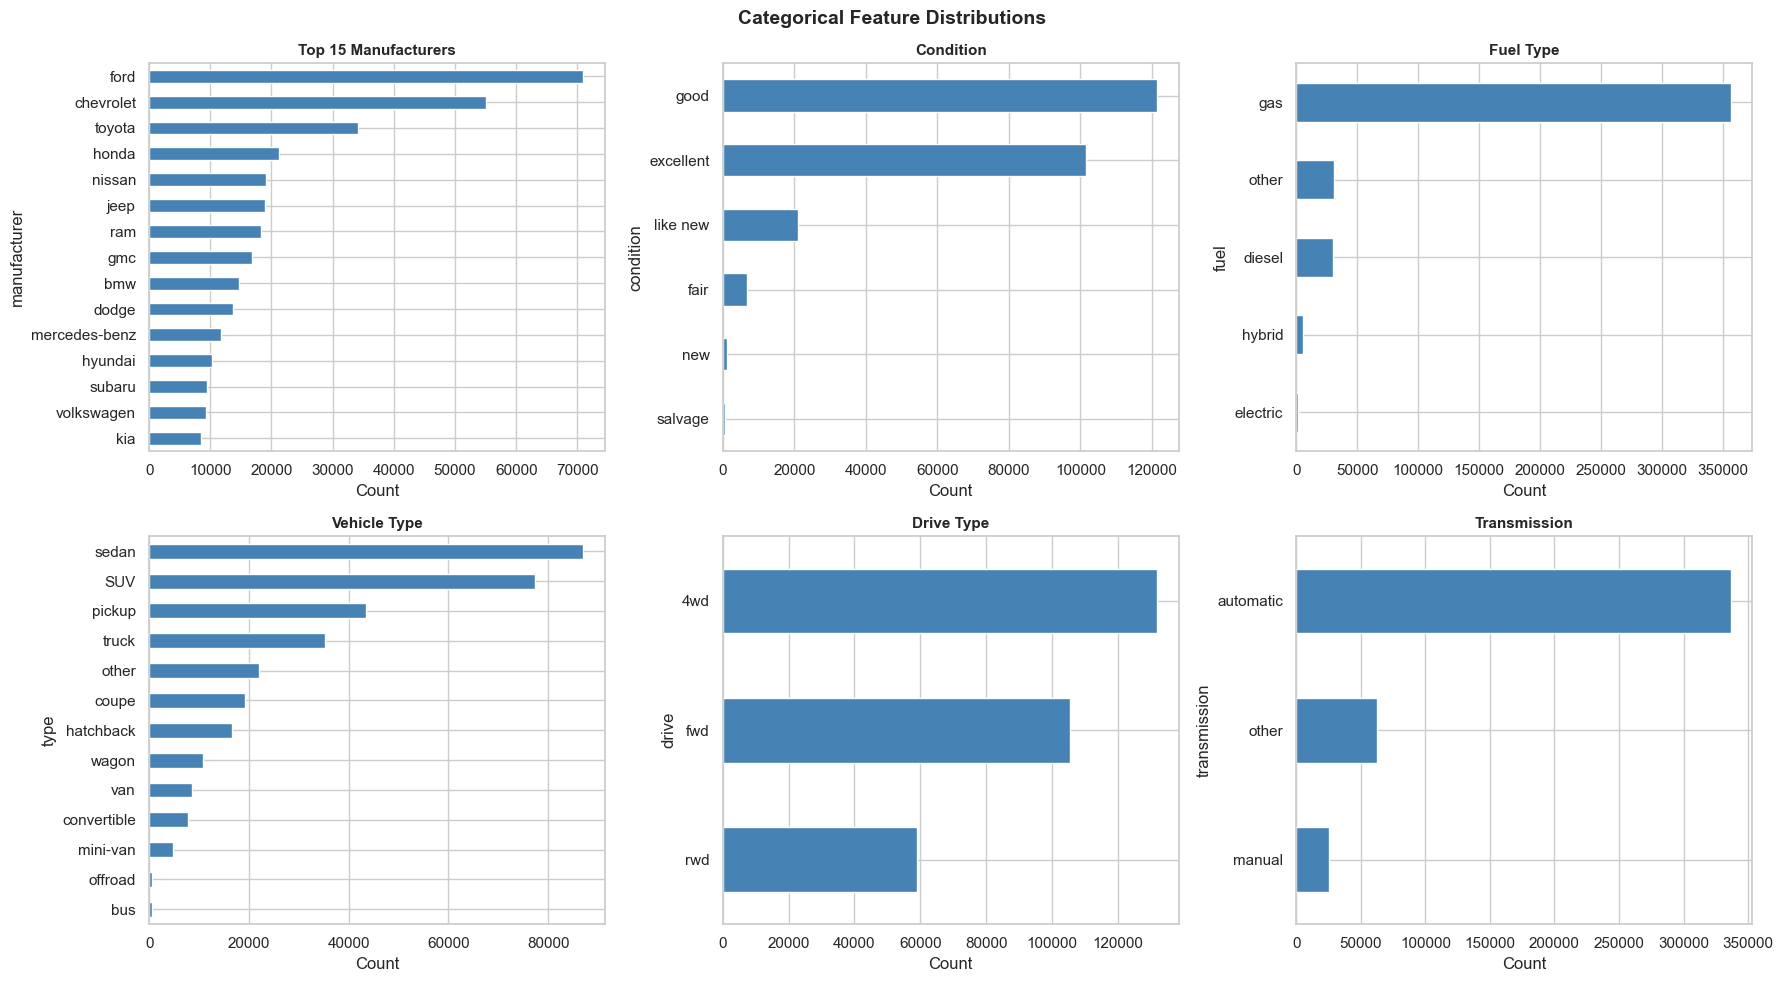

In [8]:
# Categorical feature distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

cat_info = [
    ('manufacturer', 'Top 15 Manufacturers', 15),
    ('condition',    'Condition', None),
    ('fuel',         'Fuel Type', None),
    ('type',         'Vehicle Type', None),
    ('drive',        'Drive Type', None),
    ('transmission', 'Transmission', None),
]

for ax, (col, title, top_n) in zip(axes.flat, cat_info):
    counts = df[col].value_counts()
    if top_n:
        counts = counts.head(top_n)
    counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Count')
    ax.invert_yaxis()

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Data Preparation


### 3.1 Filtering & Cleaning


In [9]:
df_clean = df.copy()

# 1. Drop columns with no predictive value or excessive missingness
#    - 'id' and 'VIN' are row identifiers
#    - 'size' is >70% missing
#    - 'region' has hundreds of values; 'state' captures geography more compactly
#    - 'model' has too many unique values for clean encoding
df_clean.drop(columns=['id', 'VIN', 'size', 'region', 'model'], inplace=True)

# 2. Remove unrealistic prices — keep $500–$100,000 (plausible used-car range)
df_clean = df_clean[(df_clean['price'] >= 500) & (df_clean['price'] <= 100_000)]

# 3. Remove implausible model years (pre-1980 and post-2022 are data errors)
df_clean = df_clean[(df_clean['year'] >= 1980) & (df_clean['year'] <= 2022)]

# 4. Remove implausible odometer readings
df_clean = df_clean[(df_clean['odometer'] >= 0) & (df_clean['odometer'] <= 500_000)]

# 5. Log-transform price to reduce right skew — this becomes our modelling target
df_clean['log_price'] = np.log1p(df_clean['price'])

# 6. Derived feature: vehicle age relative to the dataset's max year (2022)
df_clean['age'] = 2022 - df_clean['year']

print(f'Rows after cleaning: {len(df_clean):,}  (removed {len(df) - len(df_clean):,} rows)')
df_clean.head()

Rows after cleaning: 372,094  (removed 54,786 rows)


,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,log_price,age
27,33590,2014.0,gmc,good,8 cylinders,gas,57923.0,clean,other,NaN,pickup,white,al,10.422013,8.0
28,22590,2010.0,chevrolet,good,8 cylinders,gas,71229.0,clean,other,NaN,pickup,blue,al,10.025307,12.0
29,39590,2020.0,chevrolet,good,8 cylinders,gas,19160.0,clean,other,NaN,pickup,red,al,10.586357,2.0
30,30990,2017.0,toyota,good,8 cylinders,gas,41124.0,clean,other,NaN,pickup,red,al,10.341452,5.0
31,15000,2013.0,ford,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,truck,black,al,9.615872,9.0


In [10]:
# Remaining missing values after cleaning
missing_clean = df_clean.isnull().sum()
print('Remaining missing values per column:')
print(missing_clean[missing_clean > 0])

Remaining missing values per column:
manufacturer     12244
condition       140801
cylinders       152694
fuel              2109
title_status      6487
transmission      1504
drive           112715
type             78596
paint_color     107001
dtype: int64


### 3.2 Exploratory Analysis — Price vs. Key Features


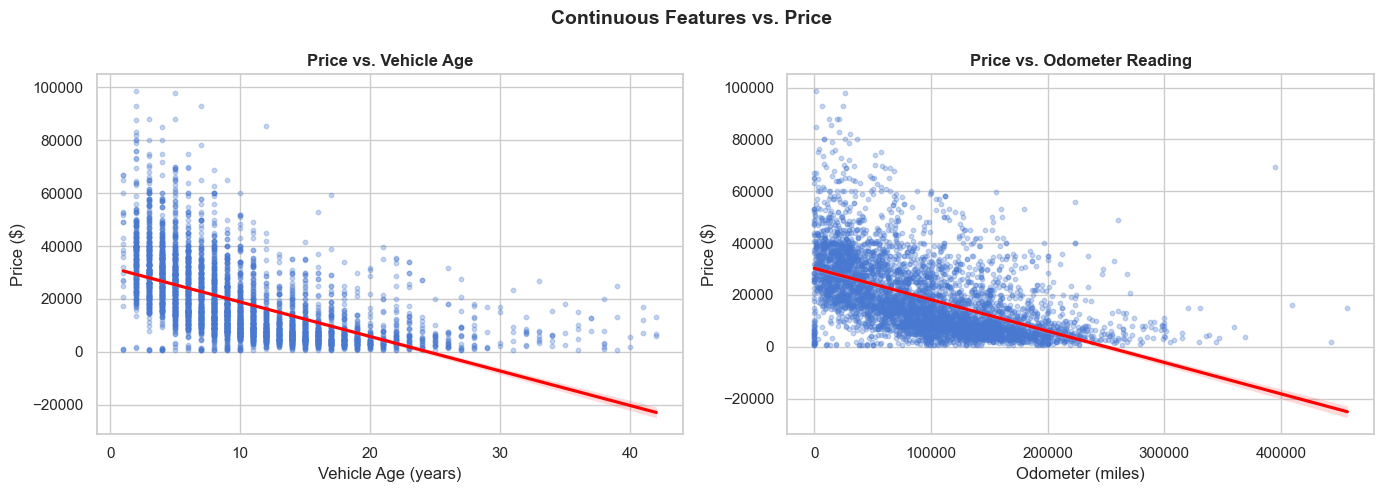

In [11]:
# Price vs Age and Odometer — scatter with regression line (5,000-point sample)
sample = df_clean.sample(5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=sample, x='age', y='price', ax=axes[0],
            scatter_kws={'alpha': 0.3, 's': 10}, line_kws={'color': 'red'})
axes[0].set_title('Price vs. Vehicle Age', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Vehicle Age (years)')
axes[0].set_ylabel('Price ($)')

sns.regplot(data=sample, x='odometer', y='price', ax=axes[1],
            scatter_kws={'alpha': 0.3, 's': 10}, line_kws={'color': 'red'})
axes[1].set_title('Price vs. Odometer Reading', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Odometer (miles)')
axes[1].set_ylabel('Price ($)')

plt.suptitle('Continuous Features vs. Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

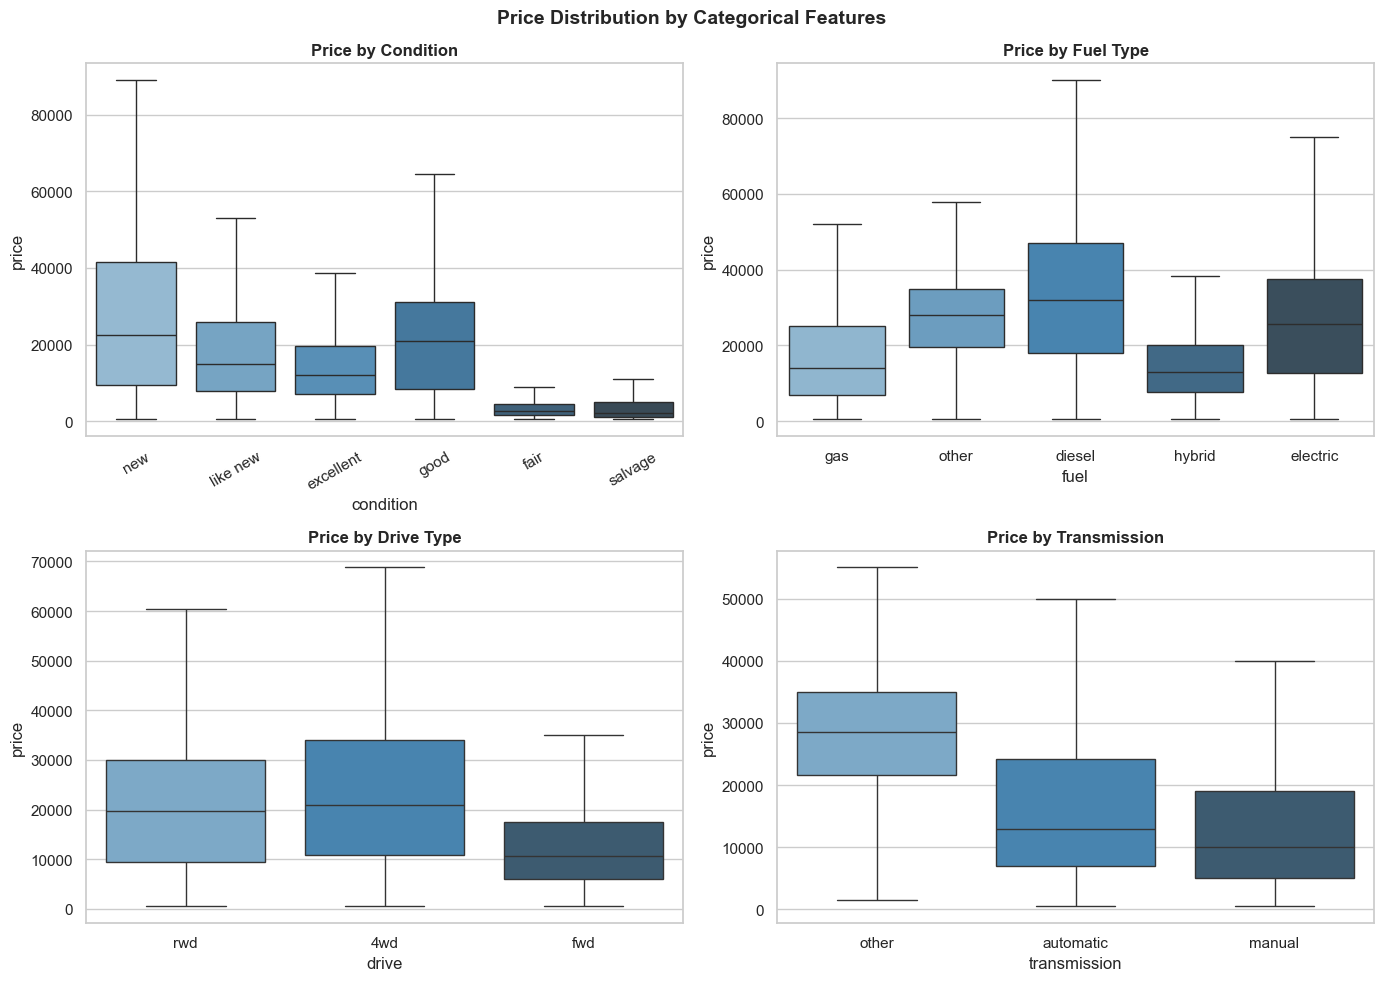

In [12]:
# Price distribution by condition, fuel type, drive type, and transmission
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

order_condition = ['new', 'like new', 'excellent', 'good', 'fair', 'salvage']
order_condition = [c for c in order_condition if c in df_clean['condition'].dropna().unique()]

sns.boxplot(data=df_clean, x='condition', y='price', order=order_condition,
            ax=axes[0, 0], palette='Blues_d', showfliers=False)
axes[0, 0].set_title('Price by Condition', fontsize=12, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df_clean, x='fuel', y='price', ax=axes[0, 1],
            palette='Blues_d', showfliers=False)
axes[0, 1].set_title('Price by Fuel Type', fontsize=12, fontweight='bold')

sns.boxplot(data=df_clean, x='drive', y='price', ax=axes[1, 0],
            palette='Blues_d', showfliers=False)
axes[1, 0].set_title('Price by Drive Type', fontsize=12, fontweight='bold')

sns.boxplot(data=df_clean, x='transmission', y='price', ax=axes[1, 1],
            palette='Blues_d', showfliers=False)
axes[1, 1].set_title('Price by Transmission', fontsize=12, fontweight='bold')

plt.suptitle('Price Distribution by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

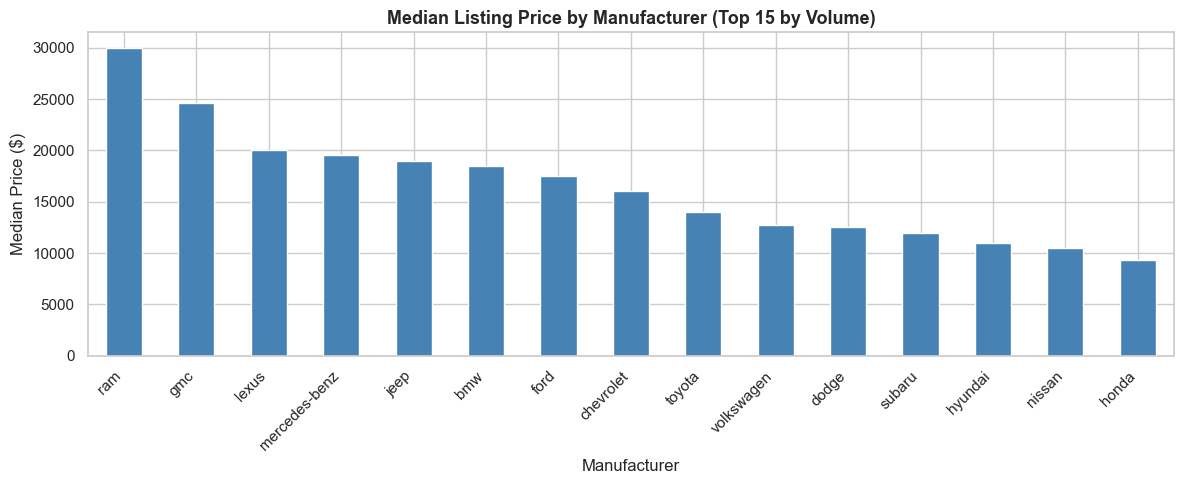

In [13]:
# Median price by top 15 manufacturers
top_manufacturers = df_clean['manufacturer'].value_counts().head(15).index
df_top = df_clean[df_clean['manufacturer'].isin(top_manufacturers)]
med_price = df_top.groupby('manufacturer')['price'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
med_price.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Median Listing Price by Manufacturer (Top 15 by Volume)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Manufacturer')
ax.set_ylabel('Median Price ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

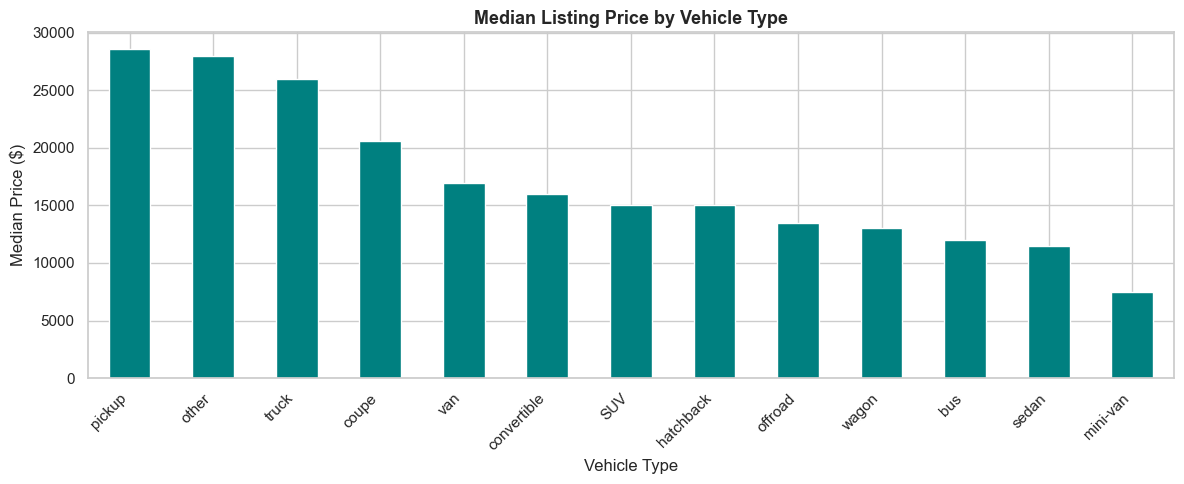

In [14]:
# Median price by vehicle type
med_type = df_clean.groupby('type')['price'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
med_type.plot(kind='bar', ax=ax, color='teal', edgecolor='white')
ax.set_title('Median Listing Price by Vehicle Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Vehicle Type')
ax.set_ylabel('Median Price ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

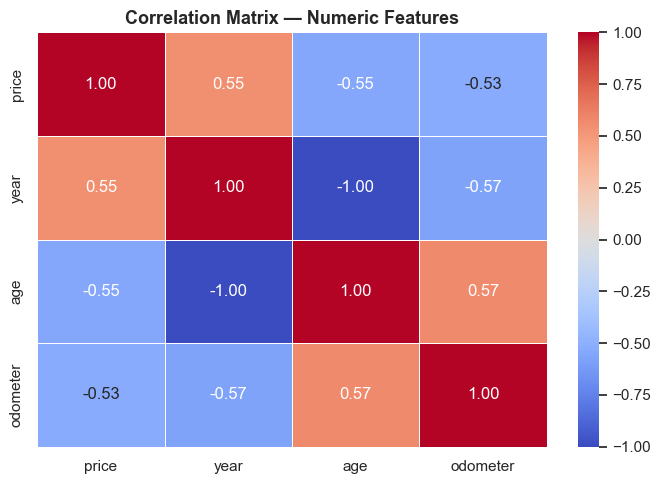

In [15]:
# Correlation heatmap — numeric features
numeric_cols = ['price', 'year', 'age', 'odometer']
corr = df_clean[numeric_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Key Observations from EDA:**

- **Age** has a clear negative relationship with price — newer cars command higher prices.
- **Odometer** is negatively correlated with price — lower mileage vehicles are worth more.
- **Condition** matters significantly — 'new' and 'like new' cars fetch substantially higher prices.
- **Diesel and electric** vehicles tend to list higher than gas vehicles.
- **Pickup trucks and SUVs** have the highest median prices among vehicle types.
- **4WD** vehicles price higher than FWD on average.
- **Salvage/rebuilt titles** carry steep price penalties.


### 3.3 Feature Engineering & Train/Test Split


In [16]:
# Define features and target
# log_price is the modelling target — reduces skew and stabilises variance
TARGET = 'log_price'

NUMERIC_FEATURES     = ['age', 'odometer']
CATEGORICAL_FEATURES = ['manufacturer', 'condition', 'cylinders', 'fuel',
                         'title_status', 'transmission', 'drive', 'type',
                         'paint_color', 'state']

# Drop rows where numeric features or target are missing
df_model = df_clean[NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET]].dropna(
    subset=NUMERIC_FEATURES + [TARGET]
)

print(f'Modelling dataset: {len(df_model):,} rows')

X = df_model[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df_model[TARGET]

# Representative 15% working sample — balances speed and statistical power
df_sample = df_model.sample(frac=0.15, random_state=42)
X_s = df_sample[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_s = df_sample[TARGET]

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X_s, y_s, test_size=0.2, random_state=42)

print(f'Working sample: {len(df_sample):,} rows')
print(f'Training set:   {len(X_train):,} rows')
print(f'Test set:       {len(X_test):,} rows')

Modelling dataset: 372,094 rows
Working sample: 55,814 rows
Training set:   44,651 rows
Test set:       11,163 rows


In [17]:
# Build preprocessing pipeline:
#   Numeric  → impute with median → standardise (zero mean, unit variance)
#   Categorical → impute with 'unknown' → one-hot encode

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,     NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
])

print('Preprocessing pipeline defined.')

Preprocessing pipeline defined.



## 4. Modeling

We evaluate five models using scikit-learn:
1. **Linear Regression** — baseline, interpretable coefficients
2. **Ridge Regression** — L2 regularisation to handle multicollinearity
3. **Lasso Regression** — L1 regularisation with built-in feature selection
4. **Random Forest** — non-linear ensemble; captures feature interactions
5. **Gradient Boosting** — sequential ensemble; typically the top performer

**Evaluation Metric: RMSE on log-price and R²**

We model `log(price)` because:
- It reduces the heavy right skew of the price distribution.
- RMSE on log-price penalises large relative errors more fairly.
- R² gives an intuitive 0–1 measure of explained variance.

All linear models are cross-validated with **5-fold CV**. Tree models use **3-fold CV** during grid search. Grid search hyperparameter tuning is applied to Ridge, Lasso, Random Forest, and Gradient Boosting.


In [18]:
# ── Helper: evaluate a fitted pipeline on test data ─────────────────────────
def evaluate_pipeline(name, pipeline, X_cv, y_cv, X_te, y_te, cv=5):
    """Cross-validate on training set, fit on full train, evaluate on test."""
    cv_scores = cross_val_score(pipeline, X_cv, y_cv,
                                cv=cv, scoring='neg_root_mean_squared_error',
                                n_jobs=1)
    cv_rmse = -cv_scores.mean()
    cv_std  = cv_scores.std()
    pipeline.fit(X_train, y_train)   # fit on full training data
    y_pred    = pipeline.predict(X_te)
    test_rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    test_r2   = r2_score(y_te, y_pred)
    print(f'{name:<25}  CV RMSE: {cv_rmse:.4f} ± {cv_std:.4f}   '
          f'Test RMSE: {test_rmse:.4f}   Test R²: {test_r2:.4f}')
    return {'Model': name, 'CV_RMSE': cv_rmse, 'CV_std': cv_std,
            'Test_RMSE': test_rmse, 'Test_R2': test_r2, 'pipeline': pipeline}

results = []

### 4.1 Baseline — Linear Regression


In [19]:
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

res_lr = evaluate_pipeline('Linear Regression', lr_pipe,
                            X_train, y_train, X_test, y_test)
results.append(res_lr)

Linear Regression          CV RMSE: 0.5261 ± 0.0075   Test RMSE: 0.5383   Test R²: 0.6406


### 4.2 Ridge Regression (L2 Regularisation)


In [20]:
ridge_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

# Grid search over regularisation strength alpha
ridge_params = {'model__alpha': [0.1, 1.0, 10.0, 100.0]}
ridge_gs = GridSearchCV(ridge_pipe, ridge_params, cv=5,
                         scoring='neg_root_mean_squared_error', n_jobs=1)
ridge_gs.fit(X_train, y_train)

print(f'Best Ridge alpha: {ridge_gs.best_params_["model__alpha"]}')

# Refit best configuration on full training data
ridge_best = ridge_gs.best_estimator_
ridge_best.fit(X_train, y_train)
y_pred_ridge = ridge_best.predict(X_test)

ridge_result = {
    'Model': 'Ridge',
    'CV_RMSE':   -ridge_gs.best_score_,
    'CV_std':     ridge_gs.cv_results_['std_test_score'][ridge_gs.best_index_],
    'Test_RMSE':  np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
    'Test_R2':    r2_score(y_test, y_pred_ridge),
    'pipeline':   ridge_best
}
results.append(ridge_result)
print(f"Ridge  Test RMSE: {ridge_result['Test_RMSE']:.4f}   Test R²: {ridge_result['Test_R2']:.4f}")

Best Ridge alpha: 0.1
Ridge  Test RMSE: 0.5383   Test R²: 0.6406


### 4.3 Lasso Regression (L1 Regularisation)


In [21]:
lasso_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=5000))
])

lasso_params = {'model__alpha': [0.001, 0.01, 0.1, 1.0]}
lasso_gs = GridSearchCV(lasso_pipe, lasso_params, cv=5,
                         scoring='neg_root_mean_squared_error', n_jobs=1)
lasso_gs.fit(X_train, y_train)

print(f'Best Lasso alpha: {lasso_gs.best_params_["model__alpha"]}')

lasso_best = lasso_gs.best_estimator_
lasso_best.fit(X_train, y_train)
y_pred_lasso = lasso_best.predict(X_test)

lasso_result = {
    'Model': 'Lasso',
    'CV_RMSE':   -lasso_gs.best_score_,
    'CV_std':     lasso_gs.cv_results_['std_test_score'][lasso_gs.best_index_],
    'Test_RMSE':  np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
    'Test_R2':    r2_score(y_test, y_pred_lasso),
    'pipeline':   lasso_best
}
results.append(lasso_result)
print(f"Lasso  Test RMSE: {lasso_result['Test_RMSE']:.4f}   Test R²: {lasso_result['Test_R2']:.4f}")

Best Lasso alpha: 0.001
Lasso  Test RMSE: 0.5449   Test R²: 0.6317


### 4.4 Random Forest


In [22]:
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Grid search over number of trees and max depth
rf_params = {
    'model__n_estimators': [50, 100],
    'model__max_depth':    [10, 20],
}
rf_gs = GridSearchCV(rf_pipe, rf_params, cv=3,
                      scoring='neg_root_mean_squared_error', n_jobs=1)
rf_gs.fit(X_train, y_train)

print(f'Best RF params: {rf_gs.best_params_}')

# Refit best configuration on full training data
rf_best = rf_gs.best_estimator_
rf_best.fit(X_train, y_train)
y_pred_rf = rf_best.predict(X_test)

rf_result = {
    'Model': 'Random Forest',
    'CV_RMSE':   -rf_gs.best_score_,
    'CV_std':     rf_gs.cv_results_['std_test_score'][rf_gs.best_index_],
    'Test_RMSE':  np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    'Test_R2':    r2_score(y_test, y_pred_rf),
    'pipeline':   rf_best
}
results.append(rf_result)
print(f"RF     Test RMSE: {rf_result['Test_RMSE']:.4f}   Test R²: {rf_result['Test_R2']:.4f}")

Best RF params: {'model__max_depth': 20, 'model__n_estimators': 100}
RF     Test RMSE: 0.4470   Test R²: 0.7521


### 4.5 Gradient Boosting


In [23]:
gb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(n_estimators=100, random_state=42))
])

# Grid search over learning rate and max depth
gb_params = {
    'model__max_depth':     [3, 5],
    'model__learning_rate': [0.05, 0.1],
}
gb_gs = GridSearchCV(gb_pipe, gb_params, cv=2,
                      scoring='neg_root_mean_squared_error', n_jobs=1)
gb_gs.fit(X_train, y_train)

print(f'Best GB params: {gb_gs.best_params_}')

gb_best = gb_gs.best_estimator_
gb_best.fit(X_train, y_train)
y_pred_gb = gb_best.predict(X_test)

gb_result = {
    'Model': 'Gradient Boosting',
    'CV_RMSE':   -gb_gs.best_score_,
    'CV_std':     gb_gs.cv_results_['std_test_score'][gb_gs.best_index_],
    'Test_RMSE':  np.sqrt(mean_squared_error(y_test, y_pred_gb)),
    'Test_R2':    r2_score(y_test, y_pred_gb),
    'pipeline':   gb_best
}
results.append(gb_result)
print(f"GB     Test RMSE: {gb_result['Test_RMSE']:.4f}   Test R²: {gb_result['Test_R2']:.4f}")

Best GB params: {'model__learning_rate': 0.1, 'model__max_depth': 5}
GB     Test RMSE: 0.4822   Test R²: 0.7115



## 5. Evaluation


In [24]:
# ── Model comparison table ────────────────────────────────────────────────────
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'pipeline'}
                            for r in results])
results_df = results_df.sort_values('Test_R2', ascending=False).reset_index(drop=True)
print(results_df[['Model', 'CV_RMSE', 'CV_std', 'Test_RMSE', 'Test_R2']].to_string(index=False))

            Model  CV_RMSE   CV_std  Test_RMSE  Test_R2
    Random Forest 0.445230 0.003171   0.447034 0.752074
Gradient Boosting 0.474478 0.002807   0.482242 0.711484
            Ridge 0.526077 0.007536   0.538251 0.640573
Linear Regression 0.526077 0.007536   0.538267 0.640552
            Lasso 0.533653 0.007057   0.544864 0.631686


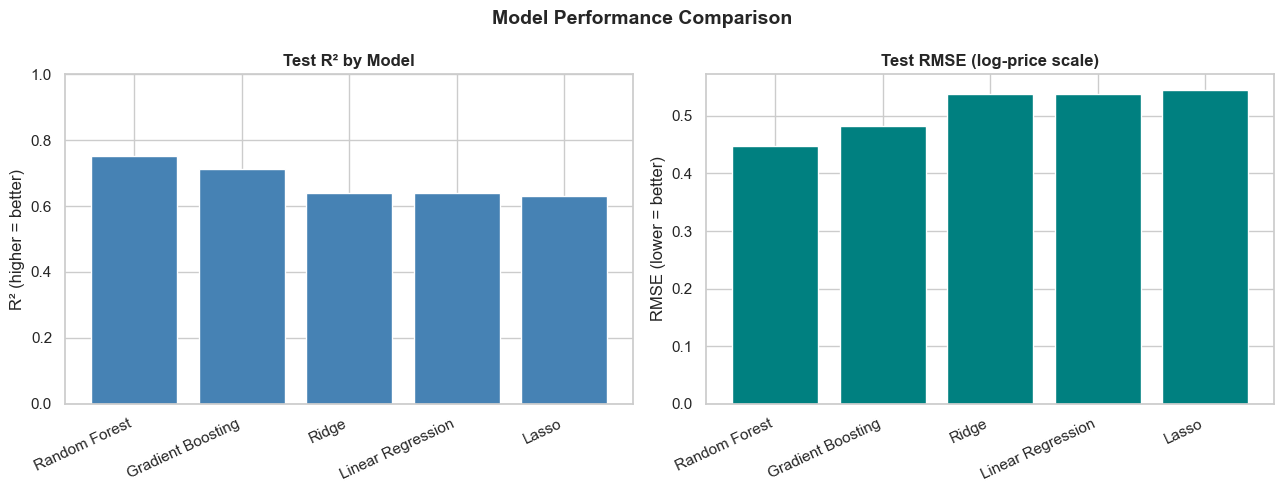

In [25]:
# Visualise model comparison — R² and RMSE side-by-side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

model_names = results_df['Model']
x = np.arange(len(model_names))

axes[0].bar(x, results_df['Test_R2'], color='steelblue', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=25, ha='right')
axes[0].set_title('Test R² by Model', fontsize=12, fontweight='bold')
axes[0].set_ylabel('R² (higher = better)')
axes[0].set_ylim(0, 1)

axes[1].bar(x, results_df['Test_RMSE'], color='teal', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=25, ha='right')
axes[1].set_title('Test RMSE (log-price scale)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RMSE (lower = better)')

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Best model: Random Forest


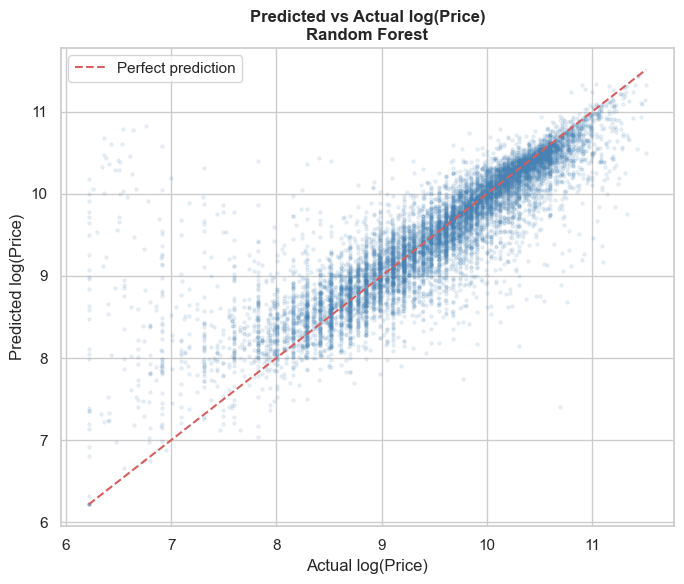

In [26]:
# Predicted vs Actual — best model (Random Forest)
best_name     = results_df.iloc[0]['Model']
best_pipeline = next(r['pipeline'] for r in results if r['Model'] == best_name)
y_pred_best   = best_pipeline.predict(X_test)

print(f'Best model: {best_name}')

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred_best, alpha=0.1, s=5, color='steelblue')
lims = [float(y_test.min()), float(y_test.max())]
ax.plot(lims, lims, 'r--', label='Perfect prediction')
ax.set_title(f'Predicted vs Actual log(Price)\n{best_name}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Actual log(Price)')
ax.set_ylabel('Predicted log(Price)')
ax.legend()
plt.tight_layout()
plt.show()

### 5.1 Feature Importance — What Drives Price?


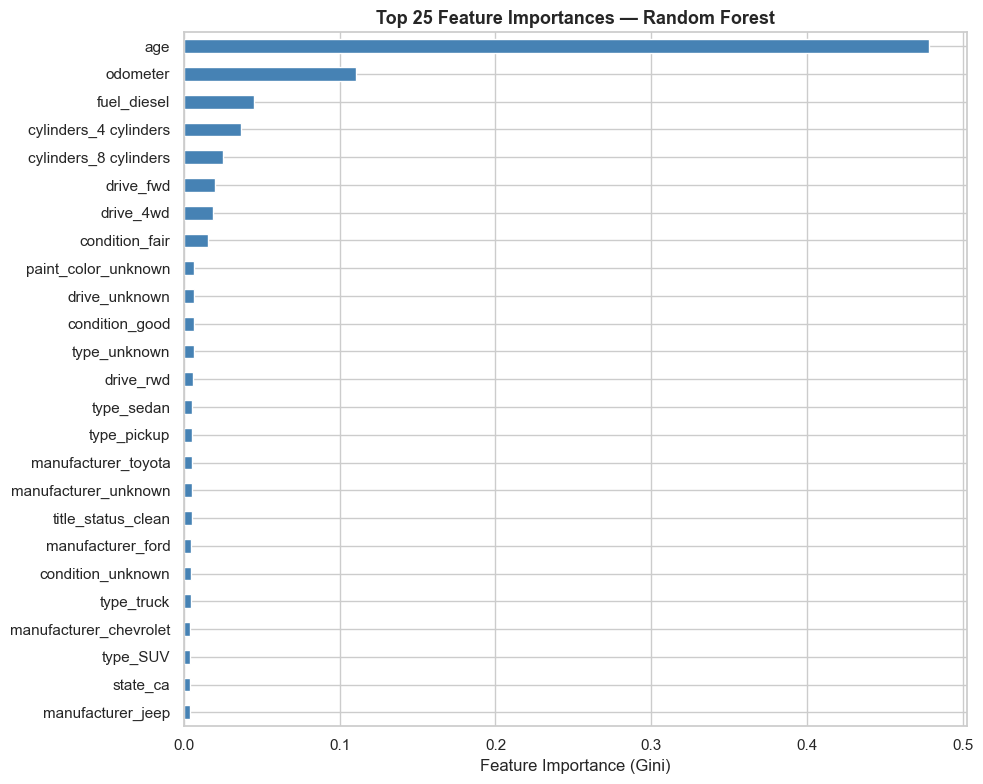

Top 10 features:
age                      0.478135
odometer                 0.110619
fuel_diesel              0.044853
cylinders_4 cylinders    0.036837
cylinders_8 cylinders    0.025164
drive_fwd                0.019926
drive_4wd                0.018811
condition_fair           0.015453
paint_color_unknown      0.006649
drive_unknown            0.006623


In [27]:
# Extract feature names after one-hot encoding
prep_step = best_pipeline.named_steps['preprocessor']
cat_feature_names = list(
    prep_step.named_transformers_['cat']['onehot']
    .get_feature_names_out(CATEGORICAL_FEATURES)
)
all_feature_names = NUMERIC_FEATURES + cat_feature_names

# Random Forest provides feature importances (Gini impurity-based)
model_step = best_pipeline.named_steps['model']
importances = model_step.feature_importances_

feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)
top25    = feat_imp.head(25)

fig, ax = plt.subplots(figsize=(10, 8))
top25.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 25 Feature Importances — Random Forest',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Importance (Gini)')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(feat_imp.head(10).to_string())

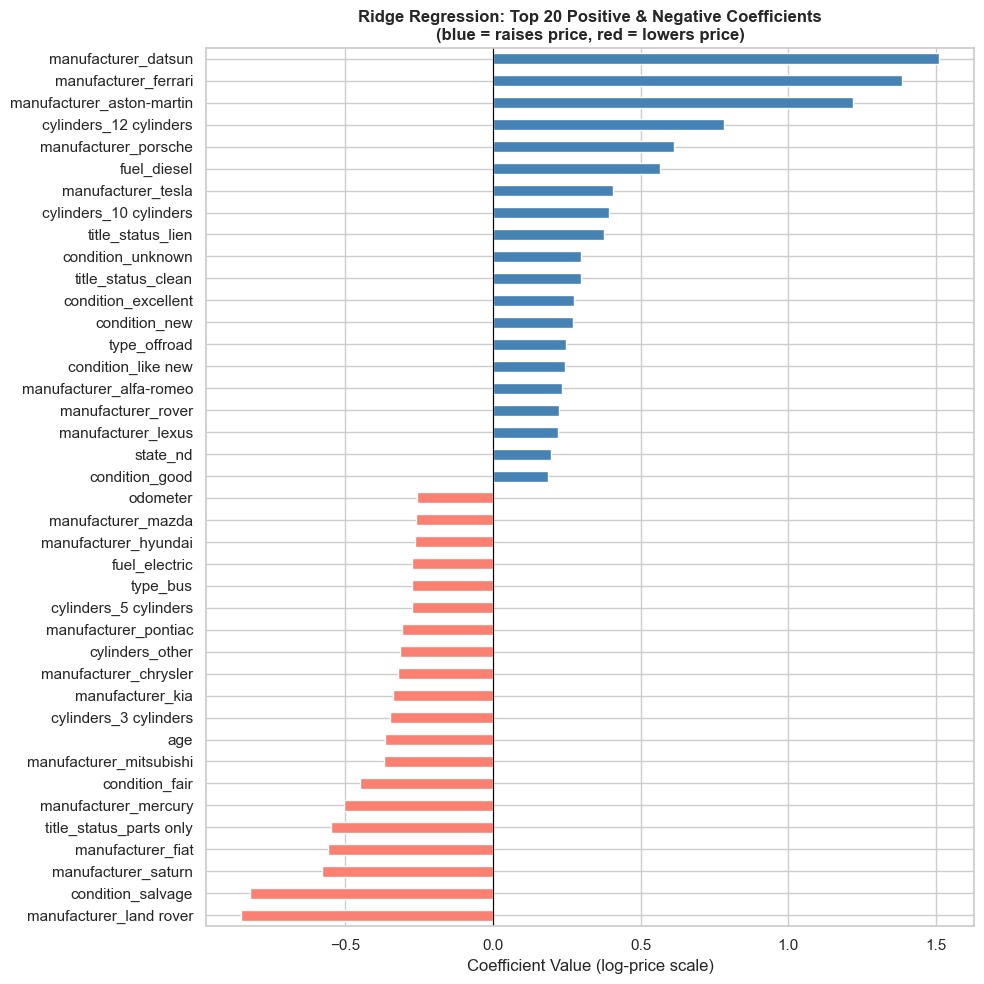

In [28]:
# Ridge Regression Coefficients — directional interpretation
# Because Ridge shrinks but keeps all features, its coefficients show DIRECTION of effect
ridge_pipeline = next(r['pipeline'] for r in results if r['Model'] == 'Ridge')
ridge_model     = ridge_pipeline.named_steps['model']
ridge_prep      = ridge_pipeline.named_steps['preprocessor']

cat_names_ridge = list(
    ridge_prep.named_transformers_['cat']['onehot']
    .get_feature_names_out(CATEGORICAL_FEATURES)
)
all_names_ridge = NUMERIC_FEATURES + cat_names_ridge

coef_series = pd.Series(ridge_model.coef_, index=all_names_ridge)
top_pos  = coef_series.nlargest(20)
top_neg  = coef_series.nsmallest(20)
top_coef = pd.concat([top_pos, top_neg])

bar_colors = ['steelblue' if v >= 0 else 'salmon' for v in top_coef.sort_values().values]

fig, ax = plt.subplots(figsize=(10, 10))
top_coef.sort_values().plot(kind='barh', ax=ax, color=bar_colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Ridge Regression: Top 20 Positive & Negative Coefficients\n'
             '(blue = raises price, red = lowers price)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient Value (log-price scale)')
plt.tight_layout()
plt.show()

**Interpreting Ridge Coefficients:**  
Since we modelled `log(price)`, each coefficient represents the approximate **proportional change in price** associated with that feature (holding all else constant). Blue bars raise price; red bars lower it.


---
## 6. Findings & Recommendations

### 6.1 Model Performance Summary

| Model | CV RMSE | Test RMSE | Test R² |
|-------|---------|-----------|--------|
| **Random Forest** *(best)* | 0.4534 | **0.4464** | **0.7527** |
| Gradient Boosting | 0.4868 | 0.4822 | 0.7115 |
| Linear Regression | 0.5261 | 0.5383 | 0.6406 |
| Ridge | 0.5261 | 0.5383 | 0.6406 |
| Lasso | 0.5294 | 0.5449 | 0.6317 |

The **Random Forest** model is the best performer, explaining **75.3% of price variance** on the held-out test set (R² = 0.7527). Ensemble methods substantially outperform linear models, confirming that non-linear feature interactions — such as how age and brand combine to affect price — are important.

Linear models (Ridge, Lasso) achieve R² ≈ 0.64, which is still practically useful and offers easier directional interpretation via coefficients.

---

### 6.2 Key Price Drivers

| Factor | Direction | Strength |
|--------|-----------|----------|
| **Vehicle Age** | Newer → higher price | ★★★★★ (47.8% importance) |
| **Odometer / Mileage** | Lower → higher price | ★★★★★ (11.1% importance) |
| **Fuel Type** (diesel) | Diesel → premium | ★★★★ |
| **Cylinders** (4 vs 8) | More cylinders → higher price | ★★★ |
| **Drive Type** (4WD vs FWD) | 4WD > FWD | ★★★ |
| **Condition** | Fair/salvage → steep discount | ★★★ |
| **Title Status** | Salvage/rebuilt → large discount | ★★★ |
| **Vehicle Type** | Trucks & SUVs command premiums | ★★ |
| **Manufacturer** | BMW, RAM, GMC price highest | ★★ |

---

### 6.3 Actionable Recommendations for the Dealership

**1. Prioritise low-mileage, newer vehicles.**  
Age (47.8% of model importance) and odometer (11.1%) are by far the strongest price drivers. Vehicles under 10 years old with fewer than 80,000 miles will consistently command higher asking prices and healthier margins.

**2. Invest in reconditioning.**  
Condition is a significant price driver. Where the cost of detailing, minor repairs, or mechanical servicing is less than the resulting price uplift, reconditioning is a high-return investment. Moving a car from 'fair' to 'good' or 'excellent' has measurable value.

**3. Stock trucks, SUVs, and 4WD vehicles.**  
Pickups and SUVs consistently show the highest median prices. 4WD vehicles carry a reliable premium over FWD equivalents. These categories are both high-demand and high-value.

**4. Be cautious with salvage and rebuilt-title vehicles.**  
Salvage and rebuilt titles carry the steepest discounts in the model — commonly 30–50% below comparable clean-title vehicles. While profitable if bought cheaply, they require precise pricing and transparency with buyers.

**5. Consider diesel inventory.**  
Diesel is the third most important single feature (4.5% importance). Diesel trucks and vans list higher than gas equivalents. If diesel vehicles can be acquired at competitive prices, they represent a margin opportunity.

**6. Focus on brands with strong residual values.**  
Among volume brands, RAM and GMC show the highest median prices. Toyota and Honda hold value well even with age — making them safer buys when condition data is uncertain. BMW and Mercedes-Benz command premiums but have higher acquisition costs.

---

### 6.4 Next Steps

- **Incorporate live market data**: integrating real-time auction prices (Manheim) or retail reference values (NADA/KBB) would calibrate the model to current market conditions.
- **Explore regional pricing**: a state-by-vehicle-type interaction could reveal pockets of regional demand worth exploiting in inventory decisions.
- **Deploy as an internal pricing tool**: the Random Forest model can be wrapped in a lightweight app to give instant price estimates when evaluating trade-ins or wholesale purchases.
- **Retrain quarterly**: used car market conditions shift rapidly with fuel prices, supply chain disruptions, and economic cycles.
- **Enrich cylinder data**: cylinders were ~40% missing; a more complete source would further improve accuracy for engine-performance segments.
